# Step-1: 1D Linear Convection

## Note:


- This is the [step-1](https://nbviewer.org/github/barbagroup/CFDPython/blob/master/lessons/01_Step_1.ipynb) in [12 steps to Navier-Stokes](https://lorenabarba.com/blog/cfd-python-12-steps-to-navier-stokes/) by Prof. Lorena Barba.


## Problem Setup

### Governing Equation

$$ \frac{ \partial u}{\partial t} + c \frac{ \partial u}{\partial x} = 0 $$

### Initial conditions



In the tutotial by Prof. Lorena Barba, she has created a step-wave, wherein the velocity is initially $u=1$, then has a sudden jump to $u=2$ at $x=0.5$ and then drops back down to $u=1$ at $x=1$. This sudden jump and fall in the value of $u$ will cause the derivative $\partial u / \partial x$ to be equal to infinity. PINNs uses $tanh$ as activation function, which will not be able to capture a sudden change in velocity. Also, the PINNs will also compute the derivative around the sudden jump/fall to be a very large value, whic will cause the residuals to be large and the model will not converge. 

So in this tutorial series, we will smoothen the step-wave so that our PINNs model is able to capture the wave and compute gradients reasonably. Following will be the modified wave function equation:    

$$ u = 1 + 0.5 \times \left[ \  tanh(k \ (x - 0.5)) - tanh(k \ (x - 1.0)) \ \right]$$

where:
- $x \in [0, 2] \ m $ is the spatial domain.
- $t \in [0, 0.5] \ s $ is the simulation duration. 

Also, for simplicity, we will assume that the wave is moving to the right and thus:
- $c = 1 \ m/s$


**The wave can be visualized below :**

In [16]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt 

# create u_initial
def create_u_initial(x_arr, k=25.0):
    
    step_up     = np.tanh(k * (x_arr - 0.5))
    step_down   = np.tanh(k * (x_arr - 1.0))
    u_init      = 1 + 0.5*(step_up - step_down)

    return u_init


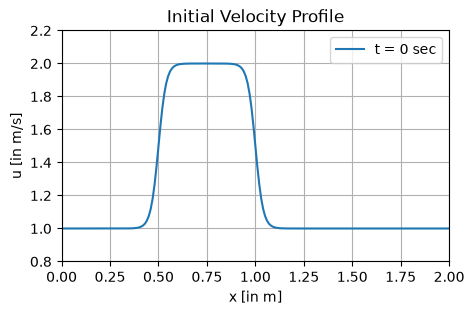

In [121]:
# visualize analytical solution
c       = 1 # wave velocity [in m/s]
x_max   = 2
t_end   = 0.5

nx      = 201 # number of grid points
nt      = 201 # number of time steps

dx      = x_max / (nx-1) # grid spacing [in m]
dt      = t_end / (nt-1) # time-step size [in s]

# Smooth step up at x=0.5 and smooth step down at x=1.0
k       = 25.0 # Steepness factor: higher values = sharper step, but harder to train.
x_arr   = np.linspace(0, x_max, nx) # x grid [in m]
u_arr   = create_u_initial(x_arr, k)

# plot
FIG_SIZE = (5, 3)
FIG_AXIS = [0, 2, 0.8, 2.2]
plt.figure(figsize=FIG_SIZE)
plt.plot(x_arr, u_arr, label="t = 0 sec")
plt.axis(FIG_AXIS)
plt.title("Initial Velocity Profile")
plt.xlabel("x [in m]")
plt.ylabel("u [in m/s]")
plt.grid("on")
plt.legend()


## Import Libraries

In [18]:
# Import libraries
import torch
import numpy as np
import deepxde as dde
import matplotlib.pyplot as plt  

# Set seed for reproducibility
dde.config.set_random_seed(42)  

# Nly: Set backend to PyTorch
dde.backend.backend_name = "pytorch"


## Select Device: CPU or GPU

### Check Availability and Select Device

In [19]:
# Check if GPU is available
print("#"*17)
print("CUDA available:", torch.cuda.is_available())
print("Default CUDA device:", torch.cuda.current_device())
print("Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
print("#"*17)
print(f"GPU available for DeepXDE: {dde.backend.is_gpu_available()}")
print("#"*17)

# Select device for computation
device = "cuda" # must be set for both PyTroch and DeepXDE ("net" variable of DeepXDE)

# Create dummy tensor for testing
torch.set_default_device(device)
a = torch.tensor([1.0, 2.0])

# print("#"*17)
print("PyTorch tensors stored in :", a.device)  # Should show: cuda:0
print("#"*17)



#################
CUDA available: True
Default CUDA device: 0
Device name: NVIDIA RTX PRO 1000 Blackwell Generation Laptop GPU
#################
GPU available for DeepXDE: True
#################
PyTorch tensors stored in : cuda:0
#################


## Implementation

### Governing PDE

The first argument to `pde` is the network input, i.e. the x and y coordinates. The second argument is the network output `u` velocity.

$$ \frac{ \partial u}{\partial t} + c \frac{ \partial u}{\partial x} = 0\ $$

In [20]:
# PDE residual  
def pde(X, u):  
    du_dx = dde.grad.jacobian(u, X, i=0, j=0)  
    du_dt = dde.grad.jacobian(u, X, i=0, j=1)  
    return du_dt + c*du_dx


### Initial Condition

In [21]:
# Initial condition (piecewise function)  
def initial_condition(X):   

    x           = X[:, 0:1]
    k           = 25.0
    u_initial   = create_u_initial(x)
    
    return u_initial 


### Boundary Condition

As we have assumed that the wave is moving to the right at $c = 1 \ m/s$ speed, the left boundary condition is fixed $u(0, t) = u(0, 0) = 1 \ m/s$. The left boundary has been defined in the following code-cell and the left boundary-condition will be defined in later section.

In [22]:
# Boundary Conditions
def boundary_left(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 0)


### Create `GeometryXTime` Domain 

In [23]:
# Geometry setup
geom        = dde.geometry.Interval(0, x_max)  
timedomain  = dde.geometry.TimeDomain(0, t_end)
geomtime    = dde.geometry.GeometryXTime(geom, timedomain)


### Create `TimePDE` Data

In [25]:
# Initial condition
ic = dde.icbc.IC(geomtime, initial_condition, lambda _, on_initial: on_initial)

# Boundary conditions - using DirichletBC at spatial boundaries
bc_left = dde.icbc.DirichletBC(geomtime, lambda x: 1.0, boundary_left) # for only left boundary

# Create TimePDE data  
data = dde.data.TimePDE(  
    geomtime,
    pde,
    [ic, bc_left],
    num_domain=2500,  
    num_boundary=100,  
    num_initial=200,  
    num_test=1000,
)


## Create PINNs Model

We use a fully connected neural network with `2` inputs, `3` hidden layers of `32` neurons width each, and `1` output.


In [26]:
# Neural network
# -> inputs  : x and t
# -> outputs : u
net = dde.nn.FNN([2] + [32]*3 + [1], "tanh", "Glorot normal")  

# Model
model = dde.Model(data, net)


## Training 

The PDE and the network have now been defined. Next, we build a `Model` and choose the optimizer and learning rate, and train it.

In [27]:
# Training  
model.compile("adam", lr=1e-3)
losshistory, train_state = model.train(iterations=10_000)

# # Optional: Continue with L-BFGS for better convergence  
# model.compile("L-BFGS-B")
# losshistory, train_state = model.train()


Compiling model...
'compile' took 1.174863 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.52e-01, 2.07e+00, 1.17e+00]    [1.49e-01, 2.07e+00, 1.17e+00]    []  


d:\Learning\venvs\test_1\Lib\site-packages\torch\autograd\graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [6.56e-04, 2.37e-02, 6.60e-05]    [6.30e-04, 2.37e-02, 6.60e-05]    []  
2000      [1.47e-04, 1.18e-02, 7.30e-05]    [1.37e-04, 1.18e-02, 7.30e-05]    []  
3000      [5.16e-05, 1.45e-03, 5.39e-06]    [4.91e-05, 1.45e-03, 5.39e-06]    []  
4000      [1.94e-05, 2.03e-04, 1.11e-06]    [1.77e-05, 2.03e-04, 1.11e-06]    []  
5000      [9.16e-06, 6.42e-05, 2.49e-06]    [8.29e-06, 6.42e-05, 2.49e-06]    []  
6000      [5.94e-06, 2.09e-05, 3.55e-06]    [5.55e-06, 2.09e-05, 3.55e-06]    []  
7000      [4.08e-06, 8.35e-06, 2.20e-06]    [3.88e-06, 8.35e-06, 2.20e-06]    []  
8000      [2.88e-06, 4.59e-06, 1.10e-06]    [2.76e-06, 4.59e-06, 1.10e-06]    []  
9000      [2.62e-06, 4.34e-06, 2.21e-06]    [2.32e-06, 4.34e-06, 2.21e-06]    []  
10000     [1.65e-06, 2.11e-06, 3.29e-07]    [1.61e-06, 2.11e-06, 3.29e-07]    []  

Best model at step 10000:
  train loss: 4.09e-06
  test loss: 4.04e-06
  test metric: []

'train' took 34.143785 s



## Save and Load Model

### Save Model

In [28]:
# Save the model after training
model.save(r"models\step_1_nn32x3_10k")


'models\\step_1_nn32x3_10k-10000.pt'

### Load Model

In [ ]:
# Create the same model structure
# net     = dde.nn.FNN([2] + [32]*3 + [1], "tanh", "Glorot normal")
# model   = dde.Model(data, net)
# model.compile("adam", lr=0.001)

# # Path to your saved model file
# checkpoint_path = r"models\step_1_nn32x3_10k-10000.pt"

# # Load the checkpoint dictionary safely
# checkpoint = torch.load(checkpoint_path, weights_only=True)

# # Inject the weights directly into the network structure
# model.net.load_state_dict(checkpoint["model_state_dict"])

# print("Model weights loaded successfully!")


Model weights loaded successfully!


## Visualize Results

Text(0.5, 1.0, '1D Linear Convection')

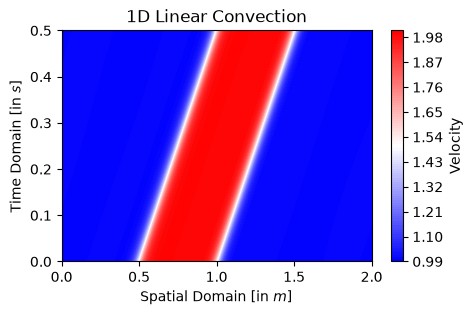

In [122]:
from matplotlib.colors import ListedColormap

# Create a grid for full 2D visualization 
x_grid  = np.linspace(0, x_max, nx)
t_grid  = np.linspace(0, t_end, nt)
X_grid, T_grid  = np.meshgrid(x_grid, t_grid)
grid_points     = np.column_stack([X_grid.ravel(), T_grid.ravel()])

# Predict u, v, p on the grid  
U_pinns = model.predict(grid_points).reshape(X_grid.shape)

# Plot contour
plt.figure(figsize=FIG_SIZE)
contour = plt.contourf(X_grid, T_grid, U_pinns, levels=100, cmap="bwr")
plt.colorbar(contour, label='Velocity')

plt.xlabel('Spatial Domain [in $m$]')
plt.ylabel('Time Domain [in $s$]')
plt.title('1D Linear Convection')
# plt.axis('equal')


In [92]:
# # plot u-initial and u-final prediction by PINNs
# plt.figure(figsize=FIG_SIZE)
# plt.plot(X_grid[0, :], U_pinns[0, :], label="t = 0 s")
# plt.plot(X_grid[-1, :], U_pinns[-1, :], label=f"t = {t_end} s")

# plt.title("Velocity Profile")
# plt.xlabel("Spatial Domain [in $m$]")
# plt.ylabel("Velocity [in $m/s$]")
# plt.axis(FIG_AXIS)
# plt.grid("on")
# plt.legend()


## Finite Difference Method (FDM)

### Setup Matrix for Implicit Scheme

In [123]:
# parameters
c   = 1
# dx  = 0.01
# dt  = 0.0025
# nx  = int(x_max/dx) + 1
# nt  = int(t_end/dt) + 1
cfl = c*dt/dx
print(f"nx  = {nx}")
print(f"nt  = {nt}")
print(f"CFL = c*dt/dx = {cfl:.3f}")

# Set up "A" matrix
A       = np.zeros((nx, nx))
alpha   = c * dt / dx

x_arr       = np.linspace(0, x_max, nx)
u_initial   = create_u_initial(x_arr)

# setup A matrix
A[0, 0]     = 1 # left boundary condition
A[-1, -2:]   = [-alpha, 1+alpha]
for i in range(1, nx-1):
    A[i, i-1:i+2] = [-alpha/2, 1, alpha/2]


nx  = 201
nt  = 201
CFL = c*dt/dx = 0.250


### Solve for All Time-Steps Upto `t_end`

In [124]:
# initialize matrix for storing all "u" values
U_fdm       = np.zeros((nt, nx))
U_fdm[0, :] = u_initial

# compute u-velocity profile for all time-steps
A_inv   = np.linalg.inv(A)
for i in range(1, nt):
    U_fdm[i, :] = np.matmul( A_inv, U_fdm[i-1, :] )


### FDM and PINNs Solution Comparison 

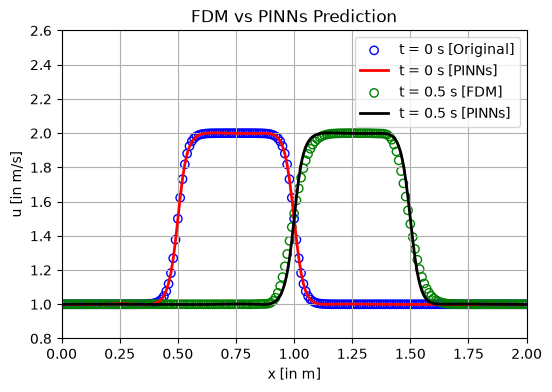

In [125]:
# plotting
plt.figure(figsize=(6, 4))
plt.title("FDM vs PINNs Prediction")

plt.scatter(x_arr, u_initial, facecolors='none', edgecolors='blue', label=f"t = 0 s [Original]")
plt.plot(X_grid[0, :], U_pinns[0, :], "r", lw=2, label="t = 0 s [PINNs]")

plt.scatter(x_arr, U_fdm[-1, :], facecolors='none', edgecolors='g', label=f"t = {t_end} s [FDM]")
plt.plot(X_grid[-1, :], U_pinns[-1, :], "k", lw=2, label=f"t = {t_end} s [PINNs]")

plt.axis([0, 2, 0.8, 2.6])
plt.xlabel("x [in m]")
plt.ylabel("u [in m/s]")
plt.grid("on")
plt.legend()


### Absolute Relative Error Contour

$$ u_{error} = \frac{ | u_{fdm} - u_{pinns} | }{ | u_{max} | } $$


Text(0.5, 1.0, 'Absolute Relative Error Contour')

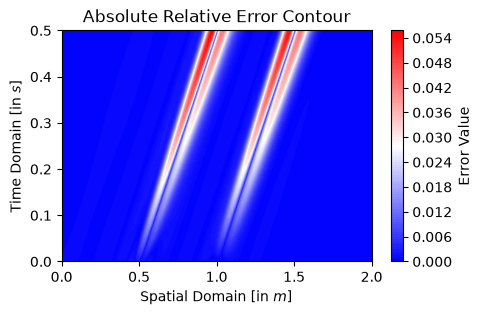

In [128]:
# Compute error 
u_max   = max(u_initial)
U_error = abs(U_fdm - U_pinns) / u_max

# Plot Error Contour
plt.figure(figsize=FIG_SIZE)
contour = plt.contourf(X_grid, T_grid, U_error, levels=100, cmap="bwr")
plt.colorbar(contour, label='Error Value', format='%.3f')

plt.xlabel('Spatial Domain [in $m$]')
plt.ylabel('Time Domain [in $s$]')
plt.title('Absolute Relative Error Contour')


## Conclusion

We see that the PINNs prediction matches very well with the FDM solution. The increasing in discrepancy between FDM and PINNs solution is due to the accumulation of numerical error in FDM, as is evident by the slight diffusion of the wave at $t=0.5 \ s$ seen in the 2D plot. Nevertheless, our objective of training a PINNs model has been achieved. In the next tutorials we will build towards a wave equation that has nonlinear convection and a diffusion term.
